In [1]:
import utils
import importlib
importlib.reload(utils)
import matplotlib.pyplot as plt
import pandas as pd

from utils import load_and_clean_data, identify_arbitrage, apply_costs, plot_arbitrage

path = r"data/2026-04-10/option_chain_nifty_2026-04-28_full_history.csv"



In [2]:
df = load_and_clean_data(path)
df = identify_arbitrage(df)
df = apply_costs(df)

In [3]:
active_df = df[df['both_legs_liquid_time_pct'] >= 100]
active_df['strike_price'].unique()

array([23000, 23500, 23800, 23900, 24000, 24100, 24200, 24500])

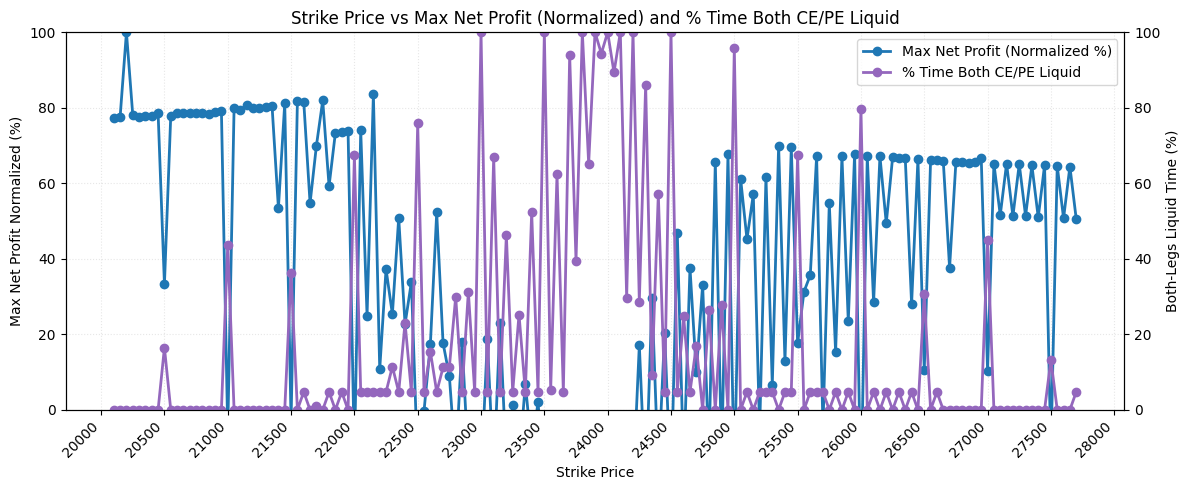

,strike_price,max_profit,max_profit_norm_pct,both_liquid_pct
0,20100,212.778612,77.198566,0.0
1,20150,213.677121,77.524556,0.0
2,20200,275.625083,100.000000,0.0
3,20250,215.174820,78.067939,0.0
4,20300,214.027990,77.651855,0.0


In [4]:
utils.plot_strike_vs_max_arbitrage_and_liquidity_pct(df, trading_cost=True).head()

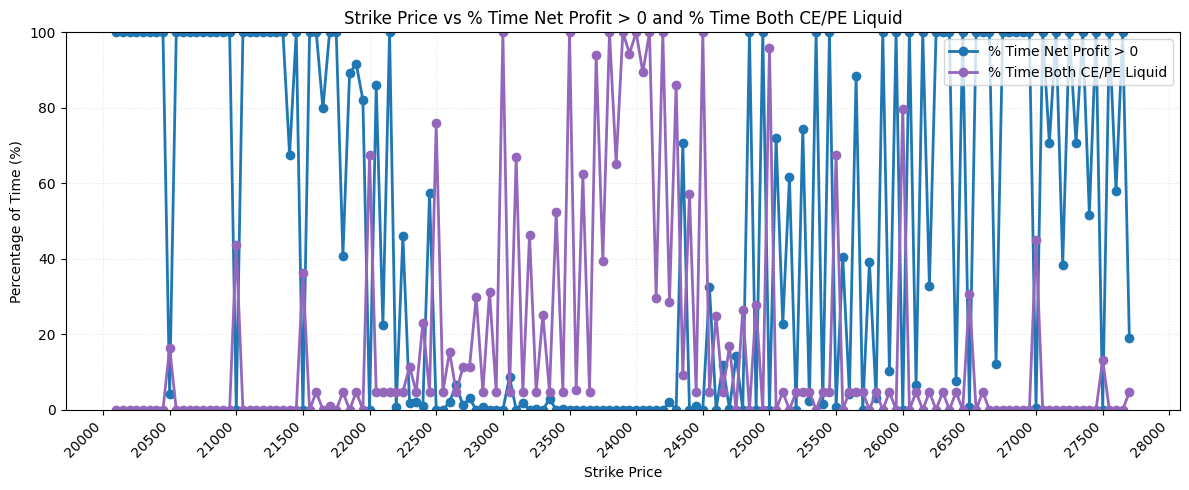

,strike_price,arbitrage_positive_pct,both_liquid_pct
0,20100,100.0,0.0
1,20150,100.0,0.0
2,20200,100.0,0.0
3,20250,100.0,0.0
4,20300,100.0,0.0


In [5]:
utils.plot_strike_vs_arbitrage_positive_and_liquidity_pct(df, trading_cost=True).head()

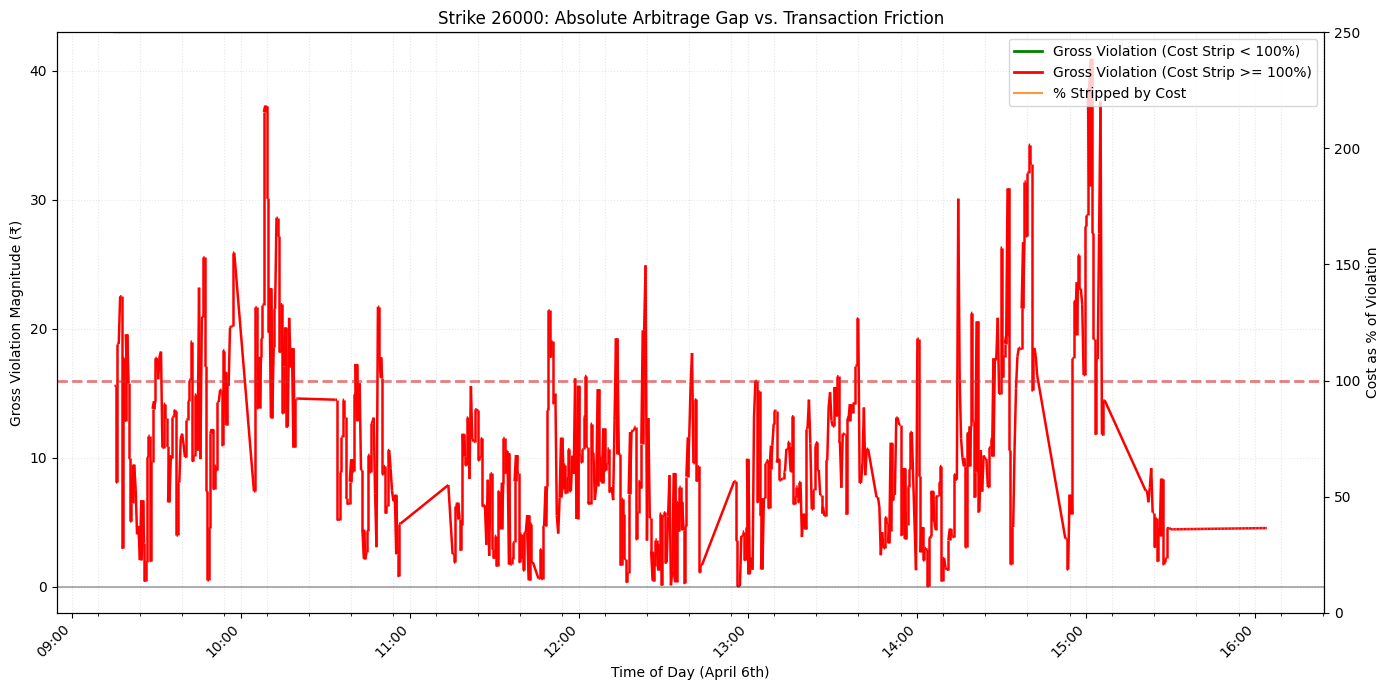

,fetch_time,abs_violation,cost,cost_stripped_pct
118,2026-04-10 09:15:00,15.575357,104.672080,672.036469
271,2026-04-10 09:15:30,15.573877,104.670434,672.089749
730,2026-04-10 09:15:30,8.073877,104.660609,1296.286826
883,2026-04-10 09:16:00,8.072398,104.658963,1296.504049
1342,2026-04-10 09:16:00,18.822398,104.672707,556.107193
...,...,...,...,...
461719,2026-04-10 16:02:00,4.529169,100.373473,2216.156511
462331,2026-04-10 16:02:30,4.530649,100.371825,2215.396297
462943,2026-04-10 16:03:00,4.532129,100.370177,2214.636579
463555,2026-04-10 16:03:30,4.533608,100.368529,2213.877358


In [6]:
utils.plot_strike_abs_violation_vs_cost_stripped_pct(df[df['both_legs_liquid'] == True], strike=26000)

In [7]:
importlib.reload(utils)

<module 'utils' from 'd:\\finmod\\Nifty50-PutCallParity-Arbitrage\\utils.py'>

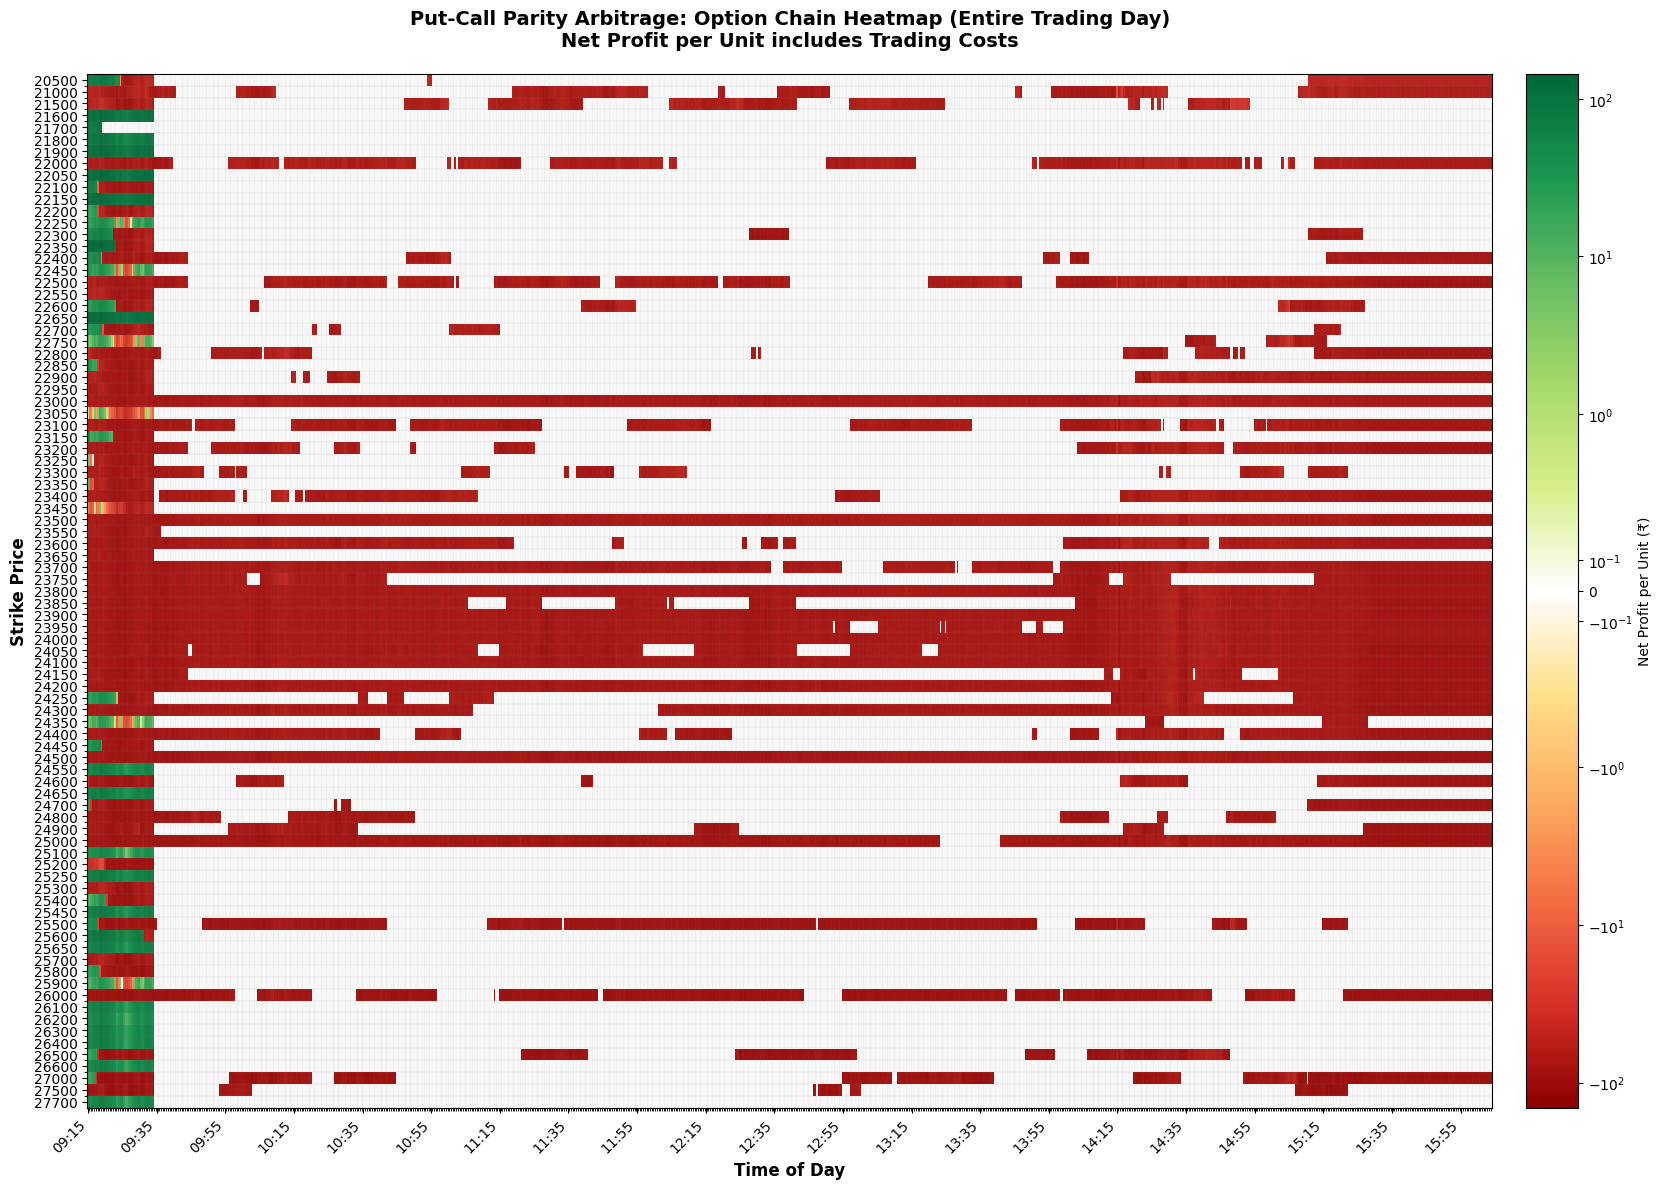

In [8]:
# COMPREHENSIVE HEATMAP: Entire Option Chain Over Entire Trading Day
# X-axis: Time of Day (09:15 to 15:30)
# Y-axis: Strike Prices (sorted)
# Color: Net Profit (Green=Profitable, Red=Loss, White=Break-even)

pivot_data = utils.plot_option_chain_heatmap_over_time(
    df[df['both_legs_liquid'] == True],  # Filter for options that were liquid at least 50% of the time
    min_liquidity=0,  # Include all data (change to e.g., 500 for more liquid options)
    trading_cost=True,
    figsize=(18, 12),
    efficiency_band_pct=0.001,  # Smaller neutral band for faster color transition
)

In [9]:
df.columns

Index(['fetch_time', 'symbol', 'expiry', 'spot_price', 'strike_price',
       'ce_growwContractId', 'ce_displayName', 'ce_longDisplayName',
       'ce_token', 'ce_marketLot', 'ce_liveData_close', 'ce_liveData_ltp',
       'ce_liveData_dayChange', 'ce_liveData_dayChangePerc', 'ce_liveData_oi',
       'ce_liveData_prevOI', 'ce_greeks_delta', 'ce_greeks_gamma',
       'ce_greeks_theta', 'ce_greeks_vega', 'ce_greeks_rho', 'ce_greeks_iv',
       'ce_greeks_pop', 'ce_markers', 'pe_growwContractId', 'pe_displayName',
       'pe_longDisplayName', 'pe_token', 'pe_marketLot', 'pe_liveData_close',
       'pe_liveData_ltp', 'pe_liveData_dayChange', 'pe_liveData_dayChangePerc',
       'pe_liveData_oi', 'pe_liveData_prevOI', 'pe_greeks_delta',
       'pe_greeks_gamma', 'pe_greeks_theta', 'pe_greeks_vega', 'pe_greeks_rho',
       'pe_greeks_iv', 'pe_greeks_pop', 'pe_markers', 'T', 'liquidity',
       'both_legs_liquid', 'both_legs_liquid_time_pct', 'market_side',
       'theoretical_side', 'violation

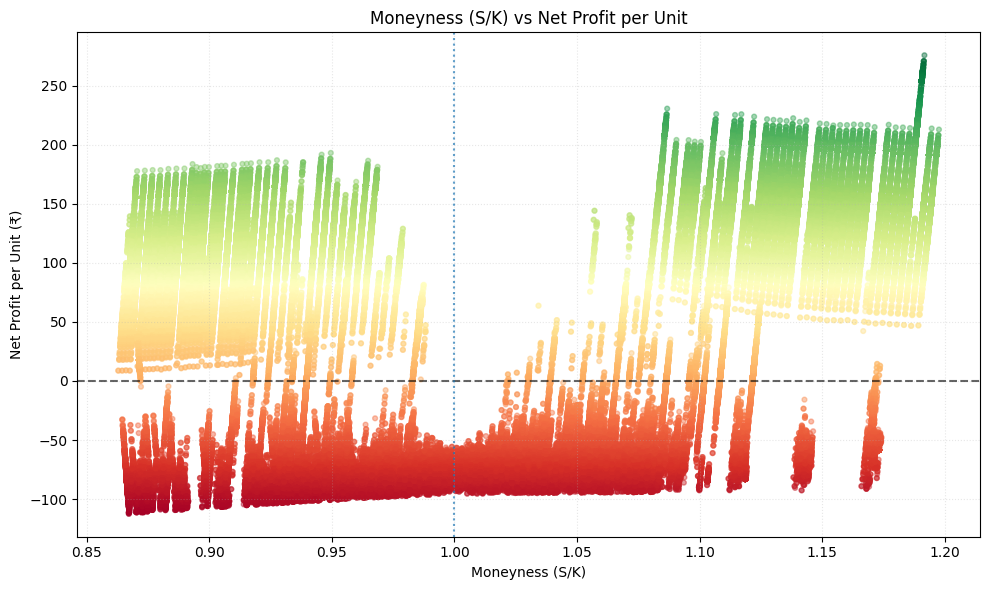

,moneyness,net_profit_per_unit
0,1.191279,88.940553
1,1.188323,92.233785
2,1.185381,90.538383
3,1.182454,92.833889
4,1.179542,93.832350


In [10]:
# SCATTER: Moneyness (S/K) vs Net Profit per Unit
moneyness_df = utils.plot_moneyness_vs_net_profit(
    df,
    min_liquidity=0,
)
moneyness_df.head()

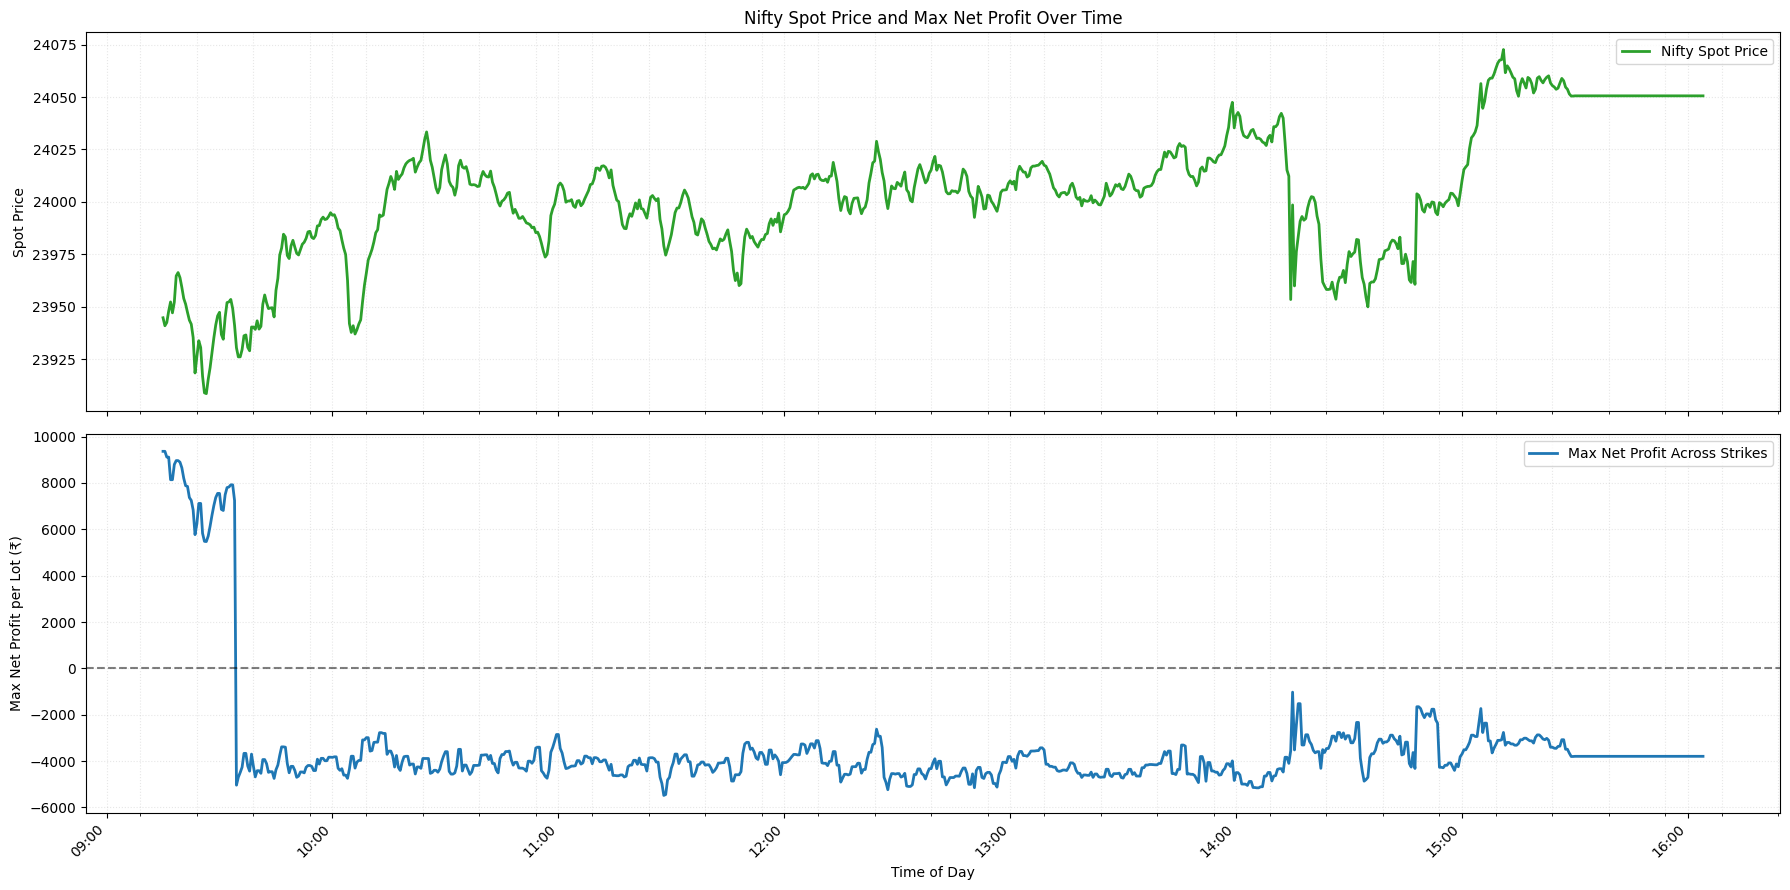

,fetch_time,spot_price,max_profit
0,2026-04-10 09:15:00,23944.700,9364.506569
1,2026-04-10 09:15:30,23940.875,9364.518508
2,2026-04-10 09:16:00,23942.450,9116.090710
3,2026-04-10 09:16:30,23947.850,9116.102750
4,2026-04-10 09:17:00,23952.250,8140.375804


In [11]:
# TWO-PANEL VIEW: Spot Price (Top) and Max Net Profit Across Strikes (Bottom)
spot_profit_df = utils.plot_spot_and_max_profit_over_time(
    df[df['both_legs_liquid'] == True],
    min_liquidity=0,
    trading_cost=True,
    per_lot=True,
    figsize=(18, 9),
)
spot_profit_df.head()

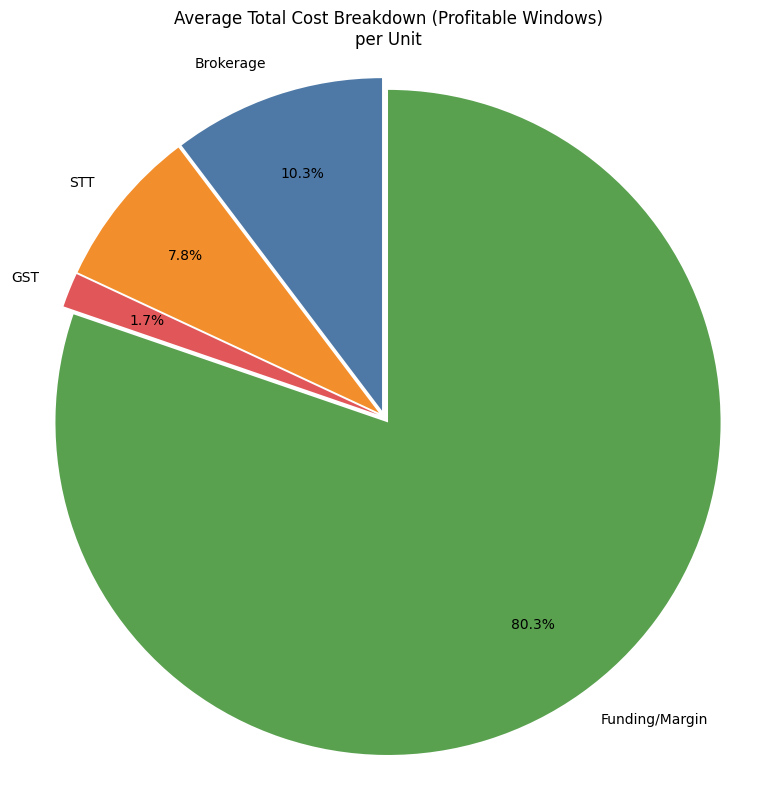

,avg_cost_per_unit
Brokerage,10.135893
STT,7.631056
GST,1.644461
Funding/Margin,78.976353
Total,98.387762


In [12]:
# COST BREAKDOWN PIE: Average total_cost in profitable windows
cost_breakdown = utils.plot_avg_cost_breakdown_pie(
    df[df['both_legs_liquid'] == True],
    profitable_only=True,
    min_liquidity=0,
    per_lot=False,
)
cost_breakdown

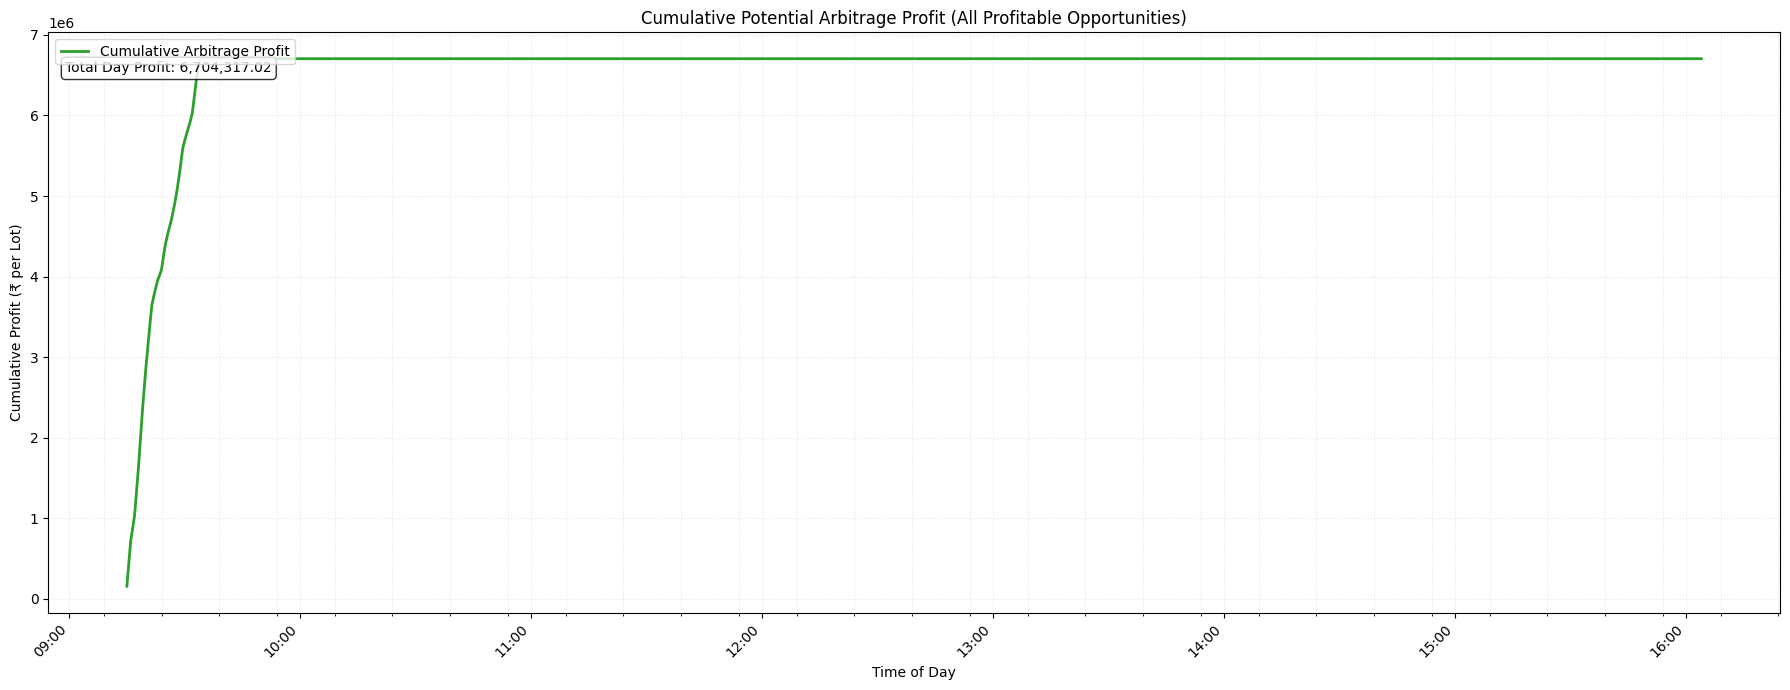

,fetch_time,interval_profit,opportunities_count,cumulative_profit
814,2026-04-10 16:02:00,0.0,0,6.704317e+06
815,2026-04-10 16:02:30,0.0,0,6.704317e+06
816,2026-04-10 16:03:00,0.0,0,6.704317e+06
817,2026-04-10 16:03:30,0.0,0,6.704317e+06
818,2026-04-10 16:04:00,0.0,0,6.704317e+06


In [14]:
# CUMSUM ARBITRAGE PROFIT: 1 lot at every profitable opportunity across strikes
cumsum_profit_df = utils.plot_cumsum_arbitrage_profit_all_opportunities(
     df[(df['both_legs_liquid'] == True)],
    require_liquid=True,
    min_liquidity=0,
    per_lot=True,
    figsize=(18, 7),
)
cumsum_profit_df.tail()